In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from dfbr.utils.files import get_path

In [ ]:
#Get total trip data
pogoh = pd.read_parquet(get_path("data\\raw\\pogoh_trips.parquet"))
pogoh_stations = pd.read_parquet(get_path("data\\raw\\pogoh_stations.parquet"))
pogoh = pogoh[pogoh['Closed Status'] == 'NORMAL']
pogoh = pd.merge(pogoh, pogoh_stations, left_on=['Start Station Id'], right_on=['Id'], how='inner')
pogoh = pd.merge(pogoh, pogoh_stations, left_on=['End Station Id'], right_on=['Id'], how='inner')
pogoh = pogoh['Start Date'].dt.date.value_counts().sort_index().to_frame(name='total_trips')


hr = pd.read_parquet(get_path("data\\raw\\healthy_ride_trips.parquet"))
hr_stations = pd.read_parquet(get_path("data\\raw\\healthy_ride_stations.parquet"))
hr = pd.merge(hr, hr_stations, left_on=['Start Station Id'], right_on=['Id'], how='inner')
hr = pd.merge(hr, hr_stations, left_on=['End Station Id'], right_on=['Id'], how='inner')
hr = hr['Start Date'].dt.date.value_counts().sort_index().to_frame(name='total_trips')



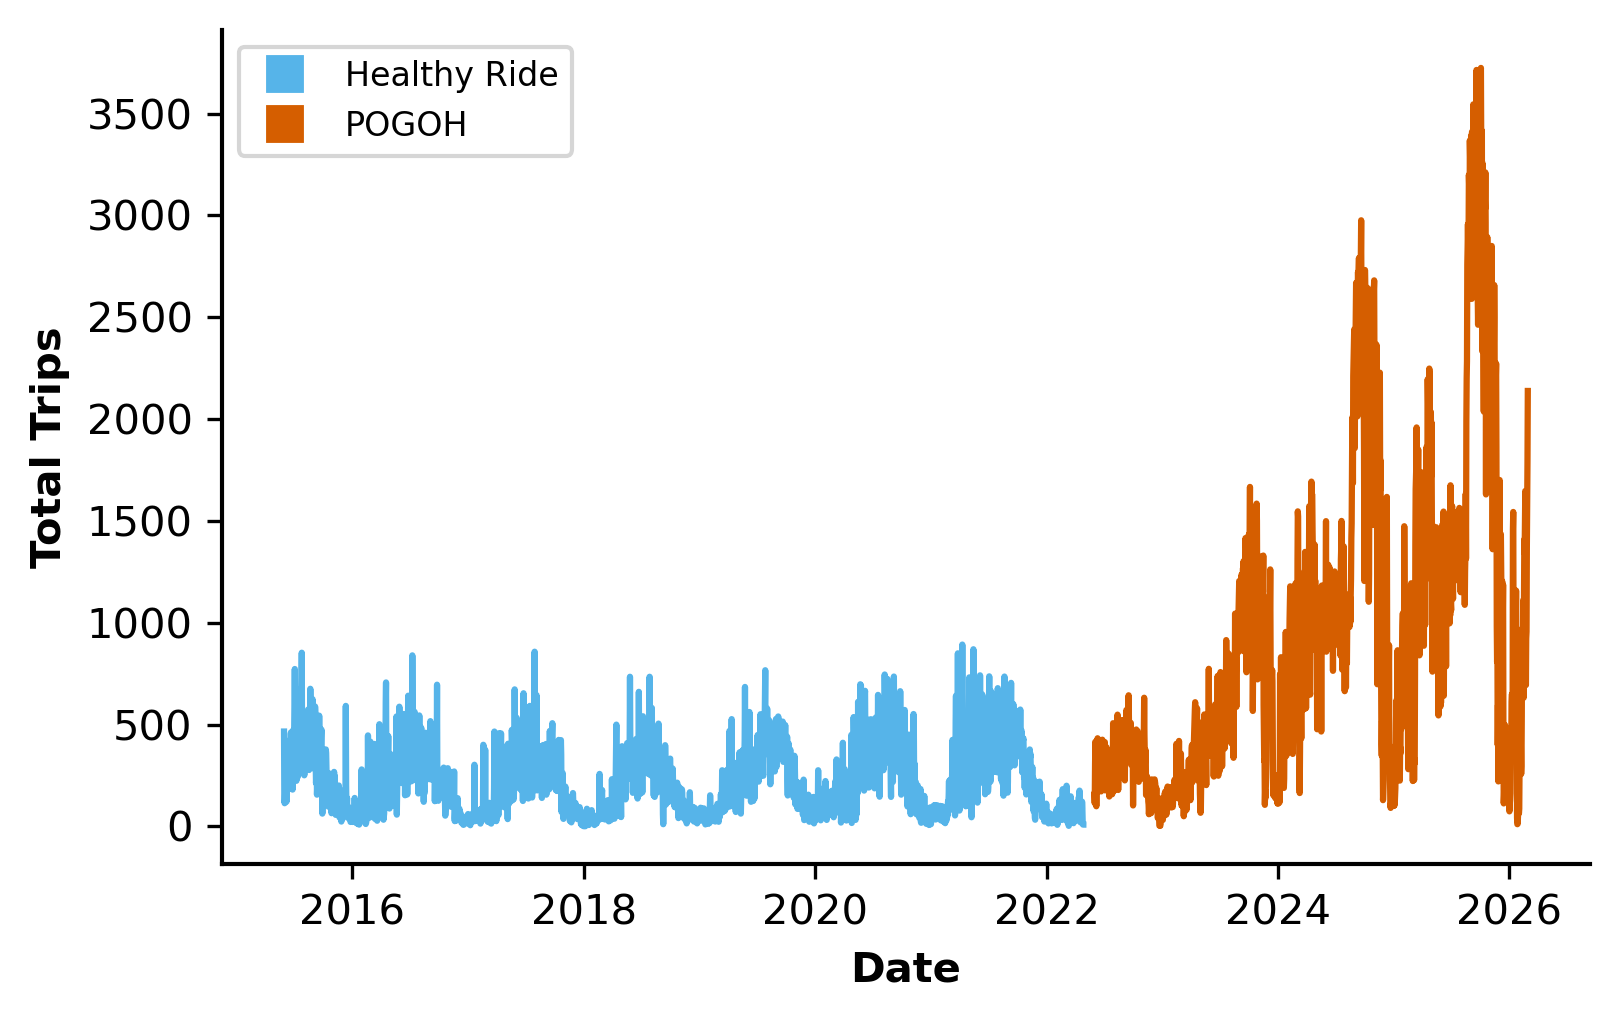

In [53]:
#Plot trajectories for moment-small-lora

#Generate plot
plt.style.use('default')
fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=300)

#Healthy Ride
ax.plot(
        hr.index, 
        hr['total_trips'],
        linestyle= "-",
        color = '#56B4E9'
)

ax.plot(
        pogoh.index, 
        pogoh['total_trips'],
        linestyle= "-",
        color = '#D55E00'
)

ax.set_xlabel('Date', fontweight='bold', fontsize=10)
ax.set_ylabel('Total Trips', fontweight='bold', fontsize=10)


legend_elements = [
    # Color indicators
    Line2D([0], [0], color='w', marker='s', markerfacecolor='#56B4E9', markersize=10, label='Healthy Ride'),
    Line2D([0], [0], color='w', marker='s', markerfacecolor='#D55E00', markersize=10, label='POGOH')
]

ax.spines['bottom'].set_linewidth(1.0)
ax.spines['left'].set_linewidth(1.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(handles=legend_elements, loc='best', frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig("plots/total_rides.pdf", format='pdf', bbox_inches='tight') 
plt.show()